In [2]:
# =========================================================
# 10_NLP_SENTIMENT_ANALYSIS.IPYNB
# =========================================================

# =========================================================
# STEP 1 — IMPORT LIBRARIES
# =========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import warnings
warnings.filterwarnings('ignore')

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Save model
import joblib

In [3]:
# =========================================================
# STEP 2 — DOWNLOAD NLTK DATA
# =========================================================

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\niran\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\niran\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [4]:
# =========================================================
# STEP 3 — LOAD DATA
# =========================================================

reviews = pd.read_csv(
    r'C:\Users\niran\Desktop\AI_Ecommerce_Customer_Intelligence_Platform\data\raw\order_reviews.csv')

print(reviews.shape)

reviews.head()

(933748, 7)


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,0ba49642-47bb-4817-9cc2-bb9ded7de7c5,c0142972-63fa-4af2-8070-f583ab769847,5,Perfect,The quality is amazing. Delivery was quick.,2019-06-19 05:08:44,2019-06-19 07:08:44
1,4e540350-1d67-4f18-bfbb-66e45e16bbc5,11bdf634-2b87-4d37-8d76-be1e7aff8f3b,5,Good,The service is excellent. Super fast shipping.,2023-04-12 23:42:33,2023-04-13 01:42:33
2,9bf68eb6-676d-4759-956e-564b7b90410c,d29b58ad-af2a-47b4-9214-b2664fb1fdba,5,Perfect,The item is fantastic. Arrived early!,2023-02-08 15:26:24,2023-02-08 17:26:24
3,17619bc8-a922-4c55-9ea6-fb027511e2fb,3d4a035e-588c-4ebd-ab6c-bf06a38cff10,5,Great,The product is good. Delivery was quick.,2022-01-26 22:36:58,2022-01-27 00:36:58
4,e41030af-afab-41f7-9a28-0098de875634,d7537ba2-da79-4a25-abaa-0b9a28452645,5,Perfect,The item is fantastic. Super fast shipping.,2021-12-18 19:09:26,2021-12-18 21:09:26


In [ ]:
# =========================================================
# STEP 4 — SELECT REQUIRED COLUMNS
# =========================================================

nlp_df = reviews[[ 'review_comment_title', 'review_comment_message', 'review_score' ]]

nlp_df.head()

,review_comment_title,review_comment_message,review_score
0,Perfect,The quality is amazing. Delivery was quick.,5
1,Good,The service is excellent. Super fast shipping.,5
2,Perfect,The item is fantastic. Arrived early!,5
3,Great,The product is good. Delivery was quick.,5
4,Perfect,The item is fantastic. Super fast shipping.,5


In [6]:
# =========================================================
# STEP 5 — HANDLE MISSING VALUES
# =========================================================

nlp_df['review_comment_title'] = nlp_df['review_comment_title'].fillna('')

nlp_df['review_comment_message'] = nlp_df['review_comment_message'].fillna('')

# Combine title + message
nlp_df['text'] = (
    nlp_df['review_comment_title'] + " " +
    nlp_df['review_comment_message']
)

# Remove empty rows
nlp_df = nlp_df[nlp_df['text'].str.strip() != '']

print(nlp_df.shape)

(933748, 4)


In [7]:
# =========================================================
# STEP 6 — CREATE SENTIMENT LABEL
# =========================================================

def sentiment_label(score):

    if score >= 4:
        return "Positive"

    elif score == 3:
        return "Neutral"

    else:
        return "Negative"

nlp_df['sentiment'] = nlp_df['review_score'].apply(sentiment_label)

nlp_df[['review_score', 'sentiment']].head()

,review_score,sentiment
0,5,Positive
1,5,Positive
2,5,Positive
3,5,Positive
4,5,Positive


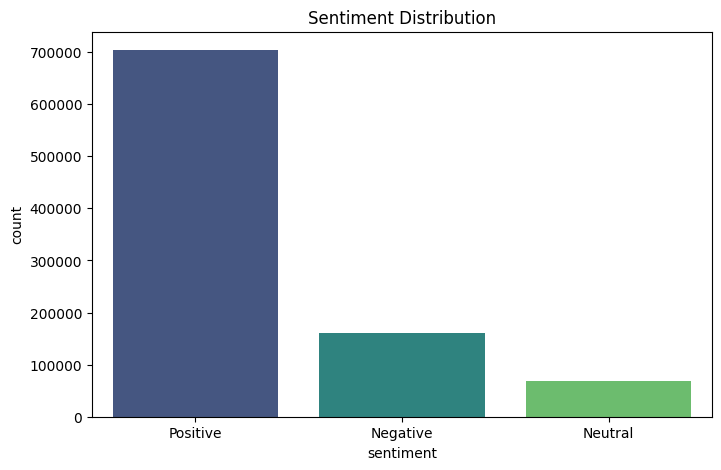

In [8]:
# =========================================================
# STEP 7 — SENTIMENT DISTRIBUTION
# =========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    x='sentiment',
    data=nlp_df,
    palette='viridis'
)

plt.title("Sentiment Distribution")
plt.show()

In [9]:
# =========================================================
# STEP 8 — TEXT CLEANING
# =========================================================

stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

def clean_text(text):

    # lowercase
    text = text.lower()

    # remove urls
    text = re.sub(r"http\S+", "", text)

    # remove numbers
    text = re.sub(r"\d+", "", text)

    # remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # remove spaces
    text = text.strip()

    # tokenize
    words = text.split()

    # remove stopwords + lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

# Apply cleaning
nlp_df['clean_text'] = nlp_df['text'].apply(clean_text)

nlp_df[['text', 'clean_text']].head()

,text,clean_text
0,Perfect The quality is amazing. Delivery was q...,perfect quality amazing delivery quick
1,Good The service is excellent. Super fast ship...,good service excellent super fast shipping
2,Perfect The item is fantastic. Arrived early!,perfect item fantastic arrived early
3,Great The product is good. Delivery was quick.,great product good delivery quick
4,Perfect The item is fantastic. Super fast ship...,perfect item fantastic super fast shipping


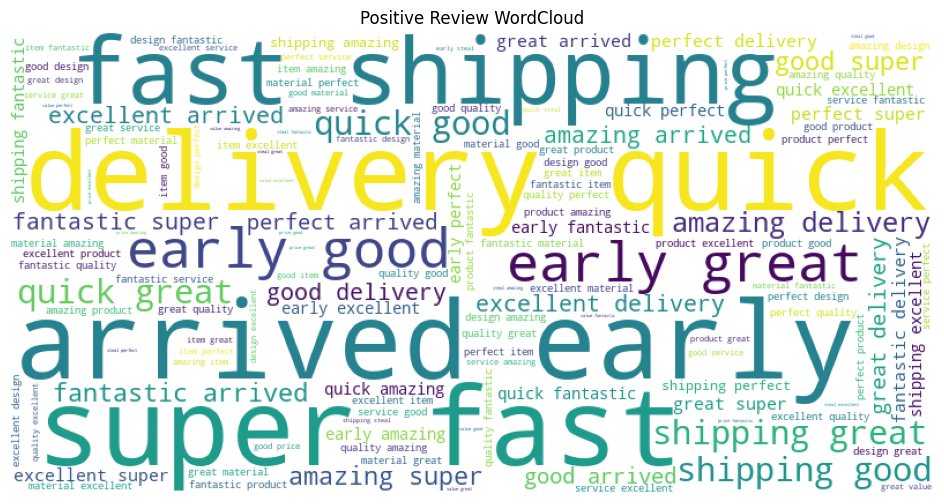

In [13]:
# =========================================================
# STEP 9 — WORD CLOUD
# =========================================================

positive_text = " ".join( nlp_df[nlp_df['sentiment']=='Positive']['clean_text'])

wordcloud = WordCloud( width=800, 
                       height=400, 
                       background_color='white').generate(positive_text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("Positive Review WordCloud")

plt.show()

In [18]:
# Check duplicate reviews

duplicate_count = nlp_df.duplicated(
    subset=['clean_text', 'sentiment_encoded']
).sum()

print("Duplicate Rows:", duplicate_count)

Duplicate Rows: 930399


In [14]:
# =========================================================
# STEP 10 — LABEL ENCODING
# =========================================================

label_mapping = { 'Negative':0, 'Neutral':1, 'Positive':2}

nlp_df['sentiment_encoded'] = ( nlp_df['sentiment'].map(label_mapping) )

In [15]:
# =========================================================
# STEP 11 — TRAIN TEST SPLIT
# =========================================================

X = nlp_df['clean_text']

y = nlp_df['sentiment_encoded']

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y )

print(X_train.shape)
print(X_test.shape)

(746998,)
(186750,)


In [19]:
# Convert to sets

train_texts = set(X_train)

test_texts = set(X_test)

# Find overlap

overlap = train_texts.intersection(test_texts)

print("Overlapping Reviews:", len(overlap))

Overlapping Reviews: 3339


In [16]:
# =========================================================
# STEP 12 — TF-IDF VECTORIZATION
# =========================================================

tfidf = TfidfVectorizer( max_features=10000 )

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)

(746998, 39)


In [17]:
# =========================================================
# STEP 13 — LOGISTIC REGRESSION
# =========================================================

lr_model = LogisticRegression( max_iter=200 )

lr_model.fit( X_train_tfidf, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test_tfidf)

# Accuracy
lr_acc = accuracy_score( y_test, y_pred_lr )

print("Logistic Regression Accuracy:")
print(lr_acc)

# Classification Report
print("\nClassification Report:\n")

print( classification_report( y_test, y_pred_lr ))

Logistic Regression Accuracy:
1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     32222
           1       1.00      1.00      1.00     13764
           2       1.00      1.00      1.00    140764

    accuracy                           1.00    186750
   macro avg       1.00      1.00      1.00    186750
weighted avg       1.00      1.00      1.00    186750



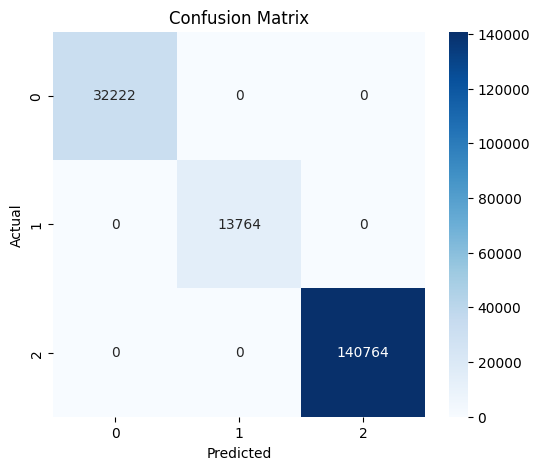

In [20]:
# =========================================================
# STEP 14 — CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [21]:
# =========================================================
# STEP 15 — NAIVE BAYES
# =========================================================

nb_model = MultinomialNB()

nb_model.fit(
    X_train_tfidf,
    y_train
)

y_pred_nb = nb_model.predict(X_test_tfidf)

nb_acc = accuracy_score(
    y_test,
    y_pred_nb
)

print("Naive Bayes Accuracy:")
print(nb_acc)


Naive Bayes Accuracy:
1.0


In [22]:
# =========================================================
# STEP 16 — ROC AUC SCORE
# =========================================================

y_prob_lr = lr_model.predict_proba(X_test_tfidf)

roc_auc = roc_auc_score(
    y_test,
    y_prob_lr,
    multi_class='ovr'
)

print("ROC-AUC Score:")
print(roc_auc)


ROC-AUC Score:
1.0


In [23]:

# =========================================================
# STEP 17 — TOP IMPORTANT WORDS
# =========================================================

feature_names = tfidf.get_feature_names_out()

coefficients = lr_model.coef_[2]

top_positive_idx = coefficients.argsort()[-20:]

top_negative_idx = coefficients.argsort()[:20]

top_positive_words = [
    feature_names[i]
    for i in top_positive_idx
]

top_negative_words = [
    feature_names[i]
    for i in top_negative_idx
]

print("Top Positive Words:")
print(top_positive_words)

print("\nTop Negative Words:")
print(top_negative_words)



Top Positive Words:
['value', 'steal', 'delivery', 'item', 'service', 'design', 'product', 'material', 'shipping', 'great', 'arrived', 'fast', 'super', 'early', 'perfect', 'excellent', 'fantastic', 'amazing', 'good', 'quick']

Top Negative Words:
['late', 'bad', 'horrible', 'disappointing', 'awful', 'terrible', 'poor', 'either', 'okay', 'average', 'overpriced', 'expensive', 'nightmare', 'money', 'worth', 'forever', 'took', 'quality', 'price', 'value']


In [24]:
# =========================================================
# STEP 18 — LSTM DEEP LEARNING MODEL
# =========================================================

max_words = 10000
max_len = 100

tokenizer = Tokenizer(
    num_words=max_words
)

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)

X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_len
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_len
)

In [25]:
# =========================================================
# STEP 19 — BUILD LSTM MODEL
# =========================================================

lstm_model = Sequential()

lstm_model.add(
    Embedding(max_words, 128, input_length=max_len)
)

lstm_model.add(
    LSTM(64, dropout=0.2, recurrent_dropout=0.2)
)

lstm_model.add(
    Dense(32, activation='relu')
)

lstm_model.add(
    Dropout(0.3)
)

lstm_model.add(
    Dense(3, activation='softmax')
)

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [26]:
# =========================================================
# STEP 20 — TRAIN LSTM MODEL
# =========================================================

history = lstm_model.fit(
    X_train_pad,
    y_train,
    epochs=3,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/3
4669/4669 ━━━━━━━━━━━━━━━━━━━━ 527s 112ms/step - accuracy: 0.9984 - loss: 0.0051 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/3
4669/4669 ━━━━━━━━━━━━━━━━━━━━ 507s 109ms/step - accuracy: 1.0000 - loss: 4.5947e-05 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/3
4669/4669 ━━━━━━━━━━━━━━━━━━━━ 484s 104ms/step - accuracy: 1.0000 - loss: 1.6446e-05 - val_accuracy: 1.0000 - val_loss: 0.0000e+00


In [27]:
# =========================================================
# STEP 21 — EVALUATE LSTM MODEL
# =========================================================

loss, accuracy = lstm_model.evaluate(
    X_test_pad,
    y_test
)

print("LSTM Accuracy:")
print(accuracy)



5836/5836 ━━━━━━━━━━━━━━━━━━━━ 92s 16ms/step - accuracy: 1.0000 - loss: 0.0000e+00
LSTM Accuracy:
1.0


In [1]:
# =========================================================
# STEP 22 — SAVE MODELS
# =========================================================

joblib.dump(
    lr_model,
    MODELS_DIR / "logistic_sentiment_model.pkl"
)

joblib.dump(
    tfidf,
    MODELS_DIR / "tfidf_vectorizer.pkl"
)

lstm_model.save(
    MODELS_DIR / "lstm_sentiment_model.h5"
)

print("NLP Models Saved Successfully")

NameError: name 'joblib' is not defined

In [30]:
# =========================================================
# STEP 23 — TEST CUSTOM REVIEW
# =========================================================

sample_review = [
    "Delivery was too late and quality was terrible"
]

sample_clean = [
    clean_text(text)
    for text in sample_review
]

sample_vector = tfidf.transform(sample_clean)

prediction = lr_model.predict(sample_vector)

reverse_mapping = {
    0:'Negative',
    1:'Neutral',
    2:'Positive'
}

print("Predicted Sentiment:")

print(
    reverse_mapping[prediction[0]]
)

Predicted Sentiment:
Negative
